# Part 1: Image Generation with Deep Convolutional GANs (DCGAN)

## Introduction


The **Deep Convolutional Generative Adversarial Network (DCGAN)** was a major breakthrough that established a stable architecture for training convolutional GANs.

DCGANs introduce several key architectural guidelines:
1.  **Replace pooling layers with strided convolutions (in the Discriminator) and fractional-strided convolutions (in the Generator).** This allows the network to learn its own spatial downsampling and upsampling.
2.  **Use Batch Normalization (BatchNorm) in both the generator and the discriminator.** This helps stabilize training by normalizing the input to each layer.
3.  **Use ReLU activation in the Generator for all layers except for the output, which uses Tanh.**
4.  **Use LeakyReLU activation in the Discriminator for all layers.**

Our goal is to implement a DCGAN from scratch to generate images of handwritten digits from the **MNIST** dataset. Your task is to build the convolutional Generator and Discriminator, and implement the training loop.

### Evaluation Metrics
Evaluation for DCGANs is the same as for simple GANs. We will rely on:

1.  **Visual Quality:** We will visually inspect the images generated by your final model.
2.  **Loss Curves:** We will monitor the Generator's loss ($L_G$) and the Discriminator's loss ($L_D$).

The underlying loss function, **Binary Cross-Entropy (BCE)**, remains the same:
$$ 
\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

## Submission
Please refer to the ```example_submission.xlsx``` to report your model with hyperparameters that achieved the best performance (measured by visual quality), as well as a full list of the models you have implemented. Your ```.ipynb``` should also be submitted.

Checklist
* ```submission_YourName.xlsx```
* ```your_dcgan_generator_weights.pth```
* ```IOAI2025_DCGAN_Test.ipynb```

> The total points of this test is **50**.

---

## Part 1: Setup and Data Loading
This section will prepare the MNIST dataset and provide helper functions for visualization.

In [1]:
!pip3 install torch torchvision matplotlib tqdm

  Using cached torch-2.7.1-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.22.1-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached matplotlib-3.10.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.14.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.6

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


### Prepare the MNIST Dataset

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Training dataset size: {len(train_dataset)}")

Training dataset size: 60000


## Q1: Implementing the DCGAN Generator (15 pts)
The Generator uses **transposed convolutions** (`nn.ConvTranspose2d`) to upsample a latent vector `z` into a full image. You are required to fill in **1 block** of code to define the generator's architecture.

In [5]:
class Generator(nn.Module):
    def __init__(self, latent_dim, ngf=64):
        super(Generator, self).__init__()
        
        # Q1.1: Define the generator network.
        # The network takes a latent vector z and upsamples it to a 28x28 image.
        # Follow the DCGAN architecture: ConvTranspose2d -> BatchNorm2d -> ReLU.
        # The final layer should use Tanh and no BatchNorm.
        # Input: (N, latent_dim, 1, 1)
        # Output: (N, 1, 28, 28)
        self.main = nn.Sequential(
            # Note: We will reshape the latent_dim vector into (N, latent_dim, 1, 1) before the forward pass.
            
            # Block 1: latent_dim -> ngf*4. Output size: 4x4
            nn.ConvTranspose2d(latent_dim, ngf * 4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # Block 2: ngf*4 -> ngf*2. Output size: 7x7 
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # Block 3: ngf*2 -> ngf. Output size: 14x14
            nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # Block 4: ngf -> 1 (num_channels). Output size: 28x28
            nn.ConvTranspose2d(ngf, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        # Reshape z from (N, latent_dim) to (N, latent_dim, 1, 1)
        z = z.view(z.size(0), -1, 1, 1)
        return self.main(z)

# Hyperparameters
latent_dim = 100

## Q2: Implementing the DCGAN Discriminator (15 pts)
The Discriminator uses strided **convolutions** (`nn.Conv2d`) to downsample an image into a single probability (logit). You are required to fill in **1 block** of code.

In [6]:
class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super(Discriminator, self).__init__()
        
        # Q2.1: Define the discriminator network.
        # It should take a 28x28 image and output a single logit.
        # Follow the DCGAN architecture: Conv2d -> BatchNorm2d -> LeakyReLU.
        # The first layer should not use BatchNorm.
        # The final layer should be a single Conv2d that outputs one channel.
        # Input: (N, 1, 28, 28)
        # Output: (N, 1, 1, 1) -> which will be squeezed to a single logit.
        self.main = nn.Sequential(
            # Block 1: 1 (num_channels) -> ndf. Output size: 14x14
            nn.Conv2d(1, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 2: ndf -> ndf*2. Output size: 7x7
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 3: ndf*2 -> 1 (output logit). Output size: 1x1
            nn.Conv2d(ndf * 2, 1, kernel_size=7, stride=1, padding=0, bias=False)
        )

    def forward(self, img):
        return self.main(img)

## Q3: The GAN Training Logic (20 pts)
The training logic is identical to a simple GAN. We must alternate between training the Discriminator and the Generator. You will fill in the two main steps inside the training loop, which should be familiar.

Epoch 1/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:12<00:00, 37.76it/s, d_loss=0.77, g_loss=1.81]


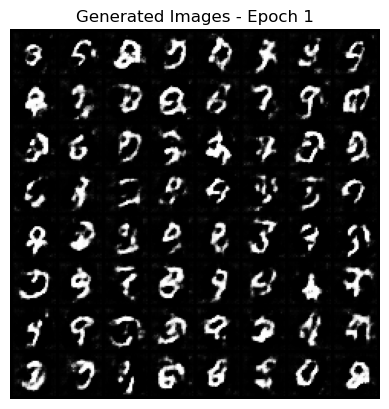

Epoch 2/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 42.46it/s, d_loss=0.897, g_loss=0.895]


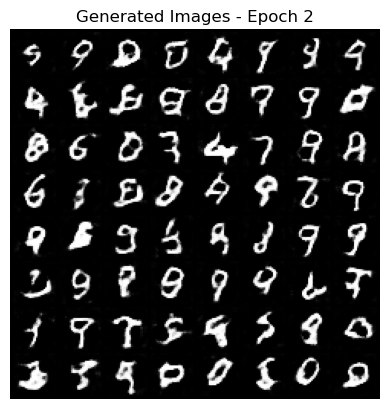

Epoch 3/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.50it/s, d_loss=1, g_loss=1.49]


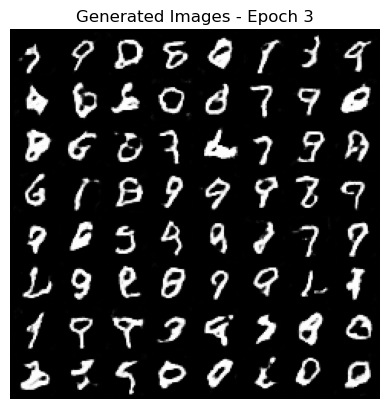

Epoch 4/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 39.86it/s, d_loss=0.94, g_loss=1.32]


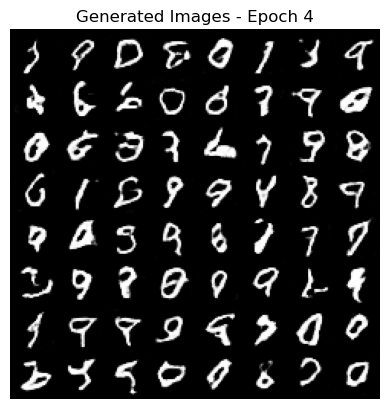

Epoch 5/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:10<00:00, 44.17it/s, d_loss=0.936, g_loss=0.995]


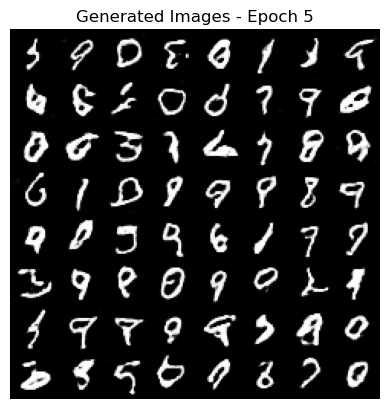

Epoch 6/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.33it/s, d_loss=0.952, g_loss=1.07]


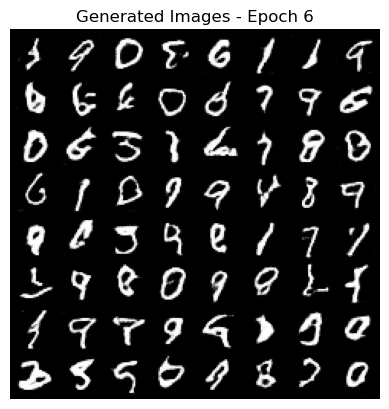

Epoch 7/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.63it/s, d_loss=0.971, g_loss=1.31]


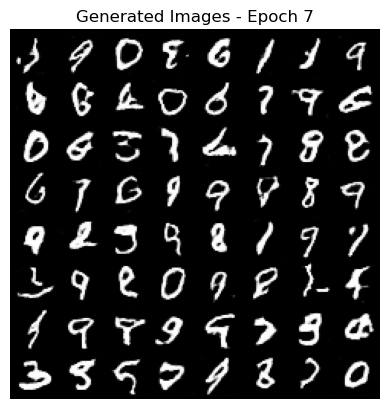

Epoch 8/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.57it/s, d_loss=1.17, g_loss=1.16]


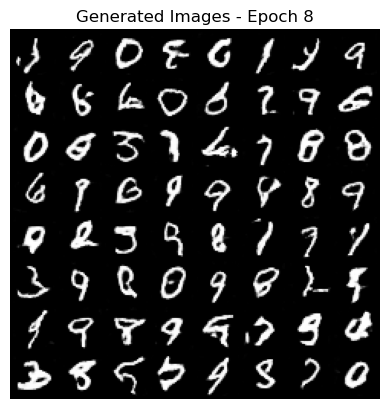

Epoch 9/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.32it/s, d_loss=1.06, g_loss=1.18]


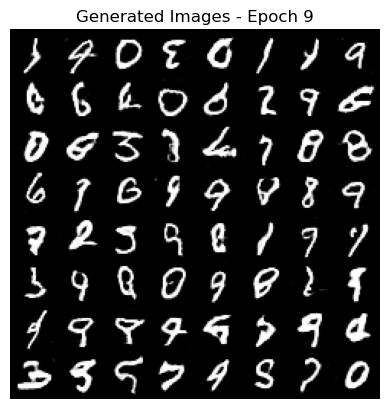

Epoch 10/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.50it/s, d_loss=1.14, g_loss=1.16]


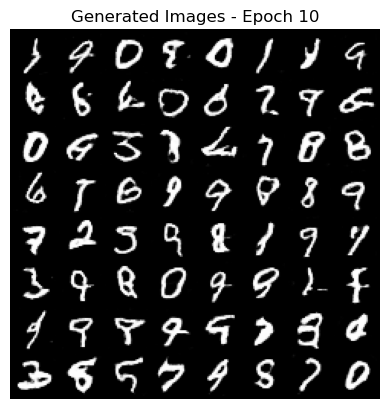

Epoch 11/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.37it/s, d_loss=1.22, g_loss=0.593]


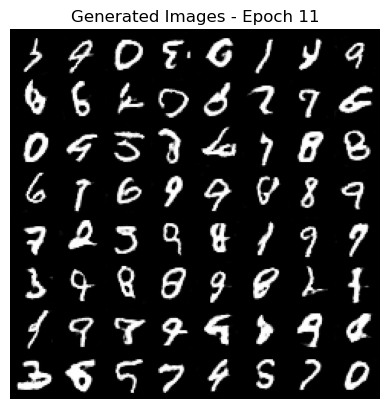

Epoch 12/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.54it/s, d_loss=0.997, g_loss=1.1]


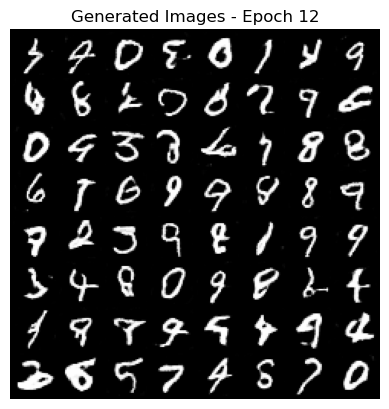

Epoch 13/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.40it/s, d_loss=1.11, g_loss=0.975]


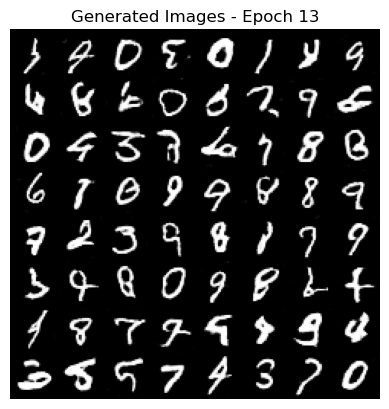

Epoch 14/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.48it/s, d_loss=1.06, g_loss=0.965]


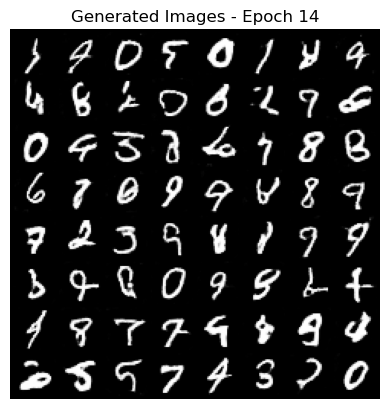

Epoch 15/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 469/469 [00:11<00:00, 40.40it/s, d_loss=1.05, g_loss=1.65]


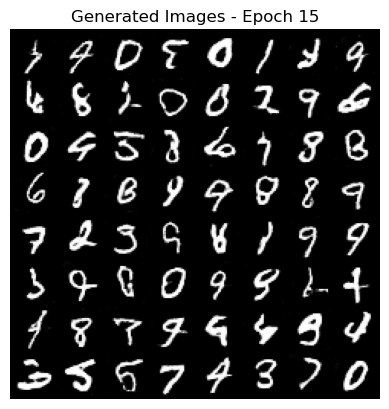

In [7]:
# Initialize models, loss, and optimizers
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()
lr = 0.0002
optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

def train_dcgan(num_epochs, train_loader):
    d_losses, g_losses = [], []
    fixed_noise = torch.randn(64, latent_dim, device=device)

    for epoch in range(num_epochs):
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for i, (real_imgs, _) in enumerate(progress_bar):

            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            real_labels = torch.ones(batch_size, 1, 1, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, 1, 1, device=device)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_d.zero_grad()
            
            # Q3.1: Implement the discriminator training step. (Approx. 4 lines)
            # 1. Calculate loss on real images.
            # 2. Generate fake images from noise `z`.
            # 3. Calculate loss on fake images (remember to use .detach()).
            # 4. Combine losses, backpropagate, and step the optimizer.
            d_loss_real = criterion(discriminator(real_imgs), real_labels)
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = generator(z)
            d_loss_fake = criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_d.step()

            # -----------------
            #  Train Generator
            # -----------------
            optimizer_g.zero_grad()
            
            # Q3.2: Implement the generator training step. (Approx. 2 lines)
            # 1. Generate a new batch of fake images.
            # 2. Calculate generator loss by trying to fool the discriminator (use `real_labels`).
            # 3. Backpropagate and step the optimizer.
            fake_imgs_for_g = generator(torch.randn(batch_size, latent_dim, device=device))
            g_loss = criterion(discriminator(fake_imgs_for_g), real_labels)
            g_loss.backward()
            optimizer_g.step()

            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            progress_bar.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

        generator.eval()
        with torch.no_grad():
            generated_imgs = generator(fixed_noise).detach().cpu()
            grid = torchvision.utils.make_grid(generated_imgs, nrow=8, normalize=True)
            plt.imshow(grid.permute(1, 2, 0))
            plt.title(f'Generated Images - Epoch {epoch+1}')
            plt.axis('off')
            plt.show()
        generator.train()

    return d_losses, g_losses

# This may take 5-10 minutes to run
d_losses, g_losses = train_dcgan(num_epochs=15, train_loader=train_loader)

### Final Visualization: Loss Curves

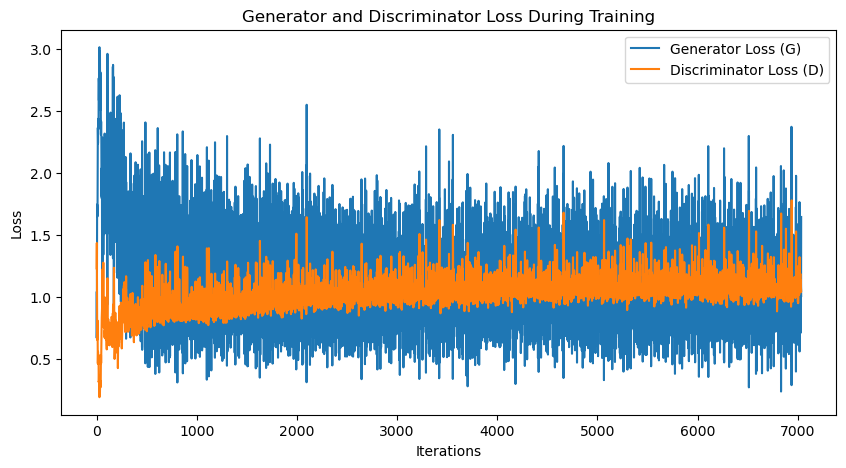

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(g_losses, label="Generator Loss (G)")
plt.plot(d_losses, label="Discriminator Loss (D)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()
